# Plotting Helpers

There are many helper functions for seamless producing publication-quality plots using matplotlib. They are located in the `plotting` library and they are structured such as to return a matplotlib figure and axis for furter manipulation and saving.

## Plot 1D distributions

There are many functions to plot 1-dimensional distributions. The simples one is `plot_hist`, which plots an array into a single histogram.

In [1]:
from analysis_helpers.plotting import plot_hist

In [2]:
import numpy as np
data = np.random.normal(loc=5, scale=1, size=1000)

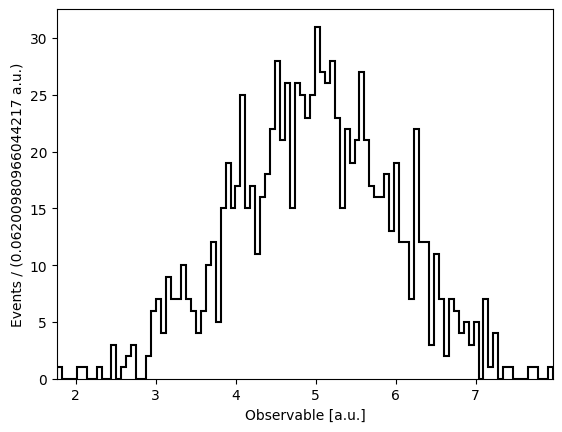

In [3]:
fig, ax = plot_hist(data, name='Observable', unit='a.u.')

Most of the functions defined in `plotting` allow keyword arguments (`**kwargs`) that are propagated to the plotting functions and allow further personalisation.

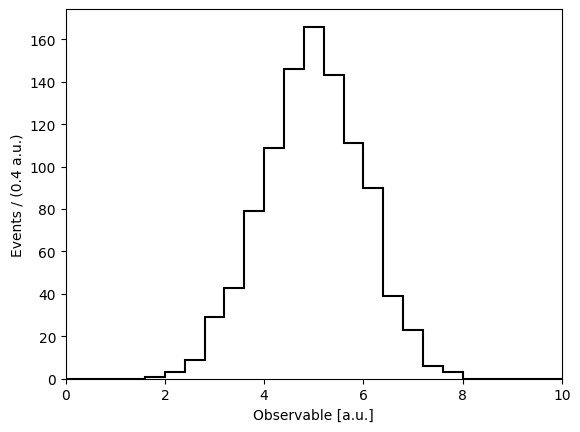

In [4]:
fig, ax = plot_hist(data, name='Observable', unit='a.u.', bins=25, range=(0,10))

It is also possible to draw the uncertainties of the bin counts on top of the histogram by specifying the flag `yerr=True`.

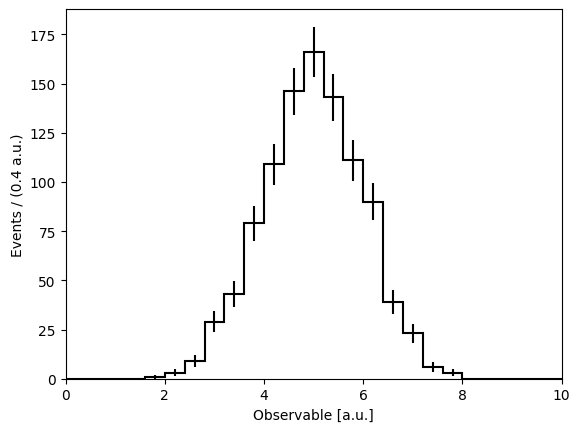

In [5]:
fig, ax = plot_hist(data, yerr=True, name='Observable', unit='a.u.', bins=25, range=(0,10))

Weighted histograms are plotted by specifying the corresponding array of weights

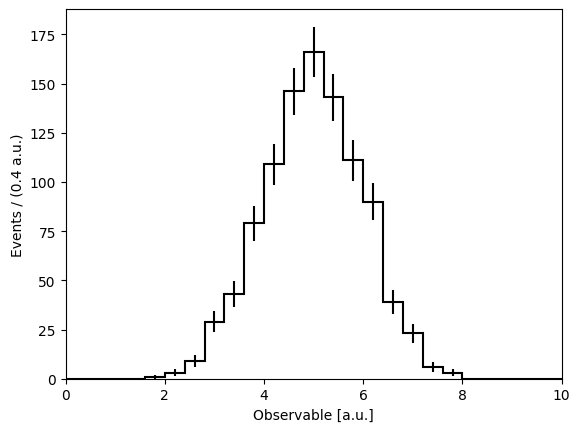

In [6]:
weights = np.random.uniform(0.5, 1.5, size=data.shape)
fig, ax = plot_hist(data, yerr=True, name='Observable', unit='a.u.', bins=25, range=(0,10), weights=weights)

Plotting normalised histograms with uncertainties is transparent with `density=True`

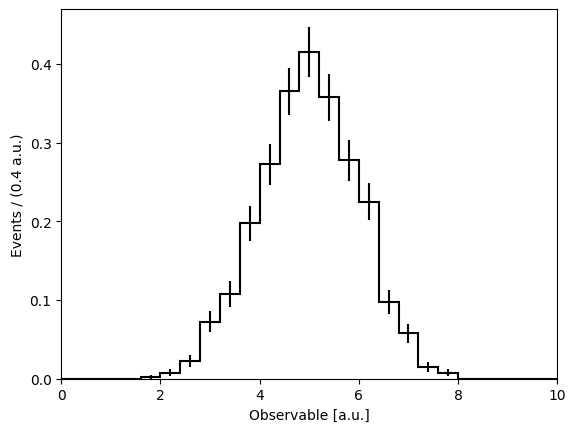

In [7]:
fig, ax = plot_hist(data, yerr=True, name='Observable', unit='a.u.', bins=25, range=(0,10), density=True)

There are also functions to draw multiple histograms on the same plot:
- `plot_hists` plots multiple sets of data

In [8]:
from analysis_helpers.plotting import plot_hists

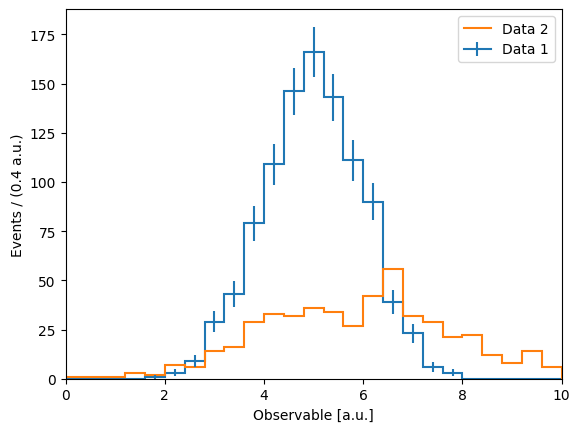

In [9]:
data2 = np.random.normal(loc=6, scale=2, size=500)
fig, ax = plot_hists([data, data2], name='Observable', unit='a.u.', bins=25, range=(0,10), weights=[weights,None], legend=['Data 1', 'Data 2'], yerrs=[True, False])

It is possible to show the candidates removed by a specific selection on the dataset

In [10]:
from analysis_helpers.plotting import plot_removed
sel = weights > 1.0

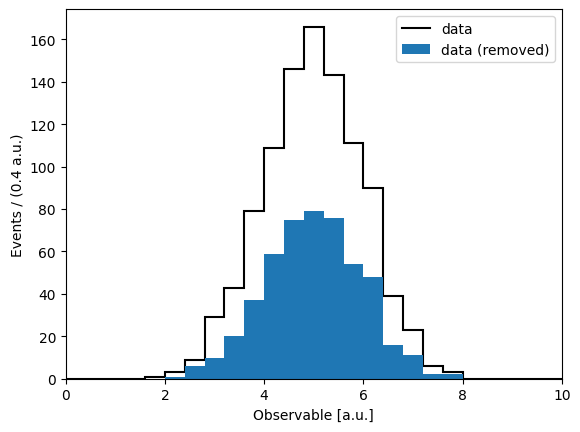

In [11]:
fig, ax = plot_removed(data, sel, name='Observable', unit='a.u.', bins=25, range=(0,10))

It is also possible to plot the efficiency projected over a specific variable by giving the selected candidates and total candidates.

/Users/maurizio/Documents/GitRepos/analysis_helpers/src/analysis_helpers/efficiency.py:161: RuntimeWarning: invalid value encountered in divide
  eff = np.divide(passed, total)


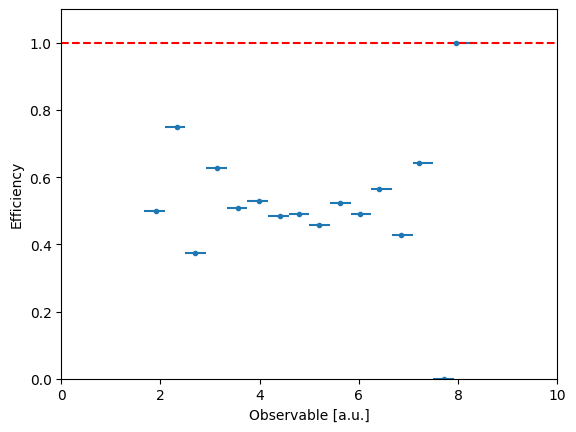

In [12]:
from analysis_helpers.plotting import plot_efficiency
fig, ax = plot_efficiency(data[sel], data, name='Observable', unit='a.u.', bins=25, range=(0,10))

## Plot 2D Distributions

2D distributions can be plotted with the `plot_hist2d` function.

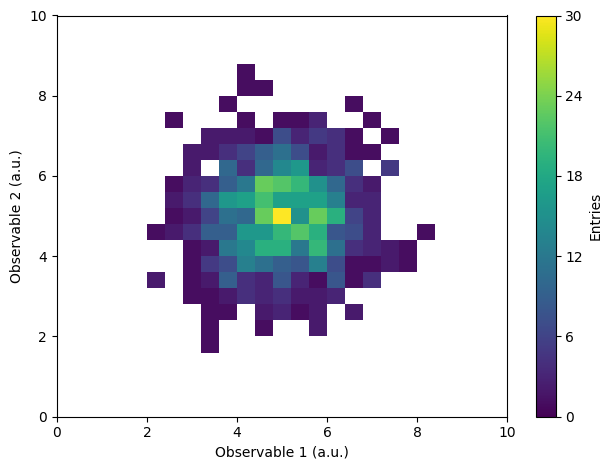

In [13]:
from analysis_helpers.plotting import plot_hist2d
data2d = np.random.normal(loc=5, scale=1, size=(1000,2))
fig, ax = plot_hist2d(data2d[:, 0], data2d[:, 1], xlabel='Observable 1 (a.u.)', ylabel='Observable 2 (a.u.)', bins=25, range=((0,10),(0,10)))

Similarly a 2D distribution of the efficiency can be plot with `plot_efficiency2d`

/Users/maurizio/Documents/GitRepos/analysis_helpers/src/analysis_helpers/efficiency.py:163: RuntimeWarning: invalid value encountered in divide
  eff_cl = np.array(wilson_interval(eff, total**2 / sumw2_total))


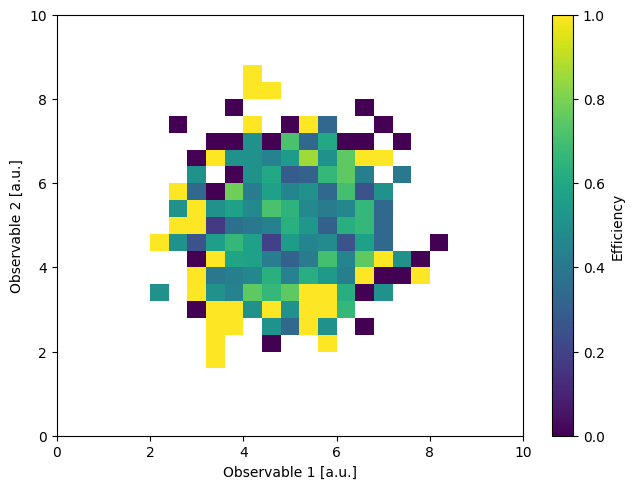

In [14]:
from analysis_helpers.plotting import plot_efficiency2d
fig, ax = plot_efficiency2d(data2d[sel], data2d, xname='Observable 1', xunit='a.u.', yname='Observable 2', yunit='a.u.', bins=25, range=((0,10),(0,10)))